# Introduction 

This notebook contains the code to compute the numerical solutions for the Kuramoto model and the windowed-solution of the complex-valued Kuramoto model. 

We recall that the Kuramoto model describes the time evolution of a set of $N$ phase oscillators, evolving on the unit circle and parametrized by an angle $\theta\in\mathbb{R}$. 
The Kuramoto model is typically formulated as the following set of ODEs 
\begin{align}
    \dot{\theta}_i = \sum_{j=1}^N a_{ij} \sin(\theta_j - \theta_i)\, ,
\end{align}
for $i\in\{1,\ldots,N\}$, where $A=(a_{ij})_{1\leq i,j\leq N}$ is the (weighted) adjacency matrix and $\boldsymbol{\theta}=(\theta_1,\theta_2,\ldots,\theta_N)$ is the vector describing the phases of the oscillators in the network. This is a highly nonlinear system of ODEs for which no closed-form solution is generally available. To compute numerical solutions, we use the RK45 method implemented in SciPy.


The complex-valued KM is described by the following ODEs where $\zeta_i \in \mathbb{C}$. 
$$ \dot{\zeta}_{i} = \sum_{j=1}^{N} a_{ij} \left[ \sin(\zeta_j-\zeta_i) -\mathrm{i}\cos(\zeta_j-\zeta_i) \right]. $$

By setting $z_i = e^{\mathrm{i} \zeta_i}$ and $\boldsymbol{z} = (z_1,...,z_N)^\top$, our work shows that $\boldsymbol{z}$ has a closed form solution 
\begin{align}
    \boldsymbol{z}(t) = e^{At} \boldsymbol{z}(0).
\end{align}

The exact solution for this equation can then be calculation by computing the exponentials of $A$. 

In [1]:
import numpy as np
import networkx as nx
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


def kuramoto_model(
    graph,
    initial_conditions,
    coupling_strength=1.0,
    time_span=(0.0, 10.0),
    time_points=1000,
):
    """
    Simulate the Kuramoto model

        d theta_i / dt
        = (K / N) sum_j a_ij sin(theta_j - theta_i),

    where omega_i = 0 and K defaults to 1.
    """

    if isinstance(graph, nx.Graph):
        node_order = list(graph.nodes())

        adjacency = nx.to_numpy_array(
            graph,
            nodelist=node_order,
            weight="weight",
            dtype=float,
        )
    else:
        adjacency = np.asarray(graph, dtype=float)
        node_order = list(range(adjacency.shape[0]))

    if adjacency.ndim != 2 or adjacency.shape[0] != adjacency.shape[1]:
        raise ValueError("The adjacency matrix must be square.")

    n = adjacency.shape[0]
    theta_0 = np.asarray(initial_conditions, dtype=float)

    if theta_0.shape != (n,):
        raise ValueError(
            f"Initial conditions must contain exactly {n} phases."
        )

    def kuramoto_equation(t, theta):
        phase_differences = (
            theta[np.newaxis, :]
            - theta[:, np.newaxis]
        )

        coupling_terms = np.sum(
            adjacency * np.sin(phase_differences),
            axis=1,
        )

        return  coupling_terms

    if np.isscalar(time_points):
        t_eval = np.linspace(
            time_span[0],
            time_span[1],
            int(time_points),
        )
    else:
        t_eval = np.asarray(time_points, dtype=float)

    result = solve_ivp(
        kuramoto_equation,
        time_span,
        theta_0,
        t_eval=t_eval,
    )

    if not result.success:
        raise RuntimeError(result.message)

    result.node_order = node_order

    return result


def kuramoto_order_parameter(phases):
    """
    Compute R(t) = (1/N) sum_j exp(i theta_j(t)).
    """
    phases = np.asarray(phases, dtype=float)
    return np.mean(np.exp(1j * phases), axis=0)

import numpy as np
import networkx as nx
from scipy.linalg import expm


def windowed_complex_kuramoto_endpoints(
    graph,
    initial_phases,
    window_size,
    number_of_windows=None,
    final_time=None,
):
    """
    Calculate only the endpoint values of the windowed
    complex-valued Kuramoto model.

    The iteration is

        z_{k+1} = exp(A * tau) exp(i * x_k),
        x_{k+1} = arg(z_{k+1}),

    where x_0 is the initial phase vector.

    Exactly one of number_of_windows or final_time must be supplied.

    Returns
    -------
    result : dict
        result["t"] : endpoint times, shape (n_windows + 1,)
        result["x"] : endpoint phases x_k, shape (N, n_windows + 1)
        result["z_before_reset"] :
            complex endpoint values immediately before each reset
        result["node_order"] : ordering of graph nodes
    """
    if isinstance(graph, nx.Graph):
        node_order = list(graph.nodes())

        adjacency = nx.to_numpy_array(
            graph,
            nodelist=node_order,
            weight="weight",
            dtype=float,
        )
    else:
        adjacency = np.asarray(graph, dtype=float)
        node_order = list(range(adjacency.shape[0]))

    if adjacency.ndim != 2 or adjacency.shape[0] != adjacency.shape[1]:
        raise ValueError("The adjacency matrix must be square.")

    if not np.allclose(adjacency, adjacency.T):
        raise ValueError("The adjacency matrix must be symmetric.")

    n = adjacency.shape[0]

    x_0 = np.asarray(initial_phases, dtype=float)

    if x_0.shape != (n,):
        raise ValueError(
            f"Initial phases must contain exactly {n} values."
        )

    if window_size <= 0:
        raise ValueError("window_size must be positive.")

    if (number_of_windows is None) == (final_time is None):
        raise ValueError(
            "Supply exactly one of number_of_windows or final_time."
        )

    if final_time is not None:
        ratio = final_time / window_size

        if not np.isclose(ratio, round(ratio)):
            raise ValueError(
                "final_time must be an integer multiple of window_size."
            )

        number_of_windows = int(round(ratio))

    if number_of_windows < 0:
        raise ValueError("number_of_windows must be nonnegative.")

    # Compute the matrix exponential only once.
    window_map = expm(adjacency * window_size)

    endpoint_phases = np.empty(
        (n, number_of_windows + 1),
        dtype=float,
    )

    endpoint_complex = np.empty(
        (n, number_of_windows + 1),
        dtype=complex,
    )

    endpoint_phases[:, 0] = x_0
    endpoint_complex[:, 0] = np.exp(1j * x_0)

    for k in range(number_of_windows):
        # Evolve the linear complex system over one window.
        z_next = (
            window_map
            @ np.exp(1j * endpoint_phases[:, k])
        )

        # Store the value immediately before resetting y to zero.
        endpoint_complex[:, k + 1] = z_next

        # Retain only the phase for the next window.
        endpoint_phases[:, k + 1] = np.angle(z_next)

    endpoint_times = (
        window_size
        * np.arange(number_of_windows + 1)
    )

    return {
        "t": endpoint_times,
        "x": endpoint_phases,
        "z_before_reset": endpoint_complex,
        "node_order": node_order,
        "adjacency": adjacency,
        "window_size": window_size,
    }

# An example 

In this example, we consider the Kuramoto model on a cycle graph of size $5$ with a random condition on $[-\pi, \pi]$

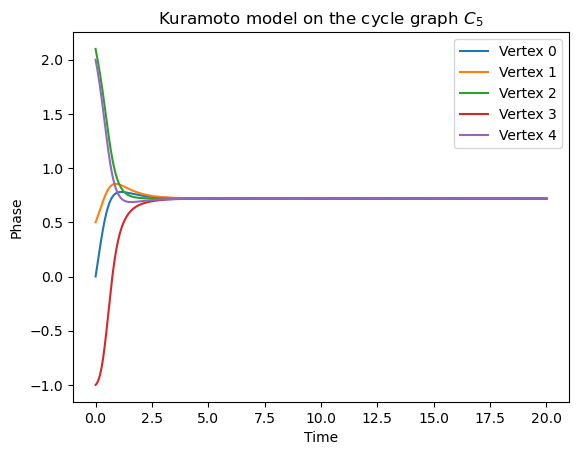

In [2]:
# Connection graph
G = nx.cycle_graph(5)

# Initial phases
theta_0 = np.array([
    0.0,
    0.5,
    2.1,
    -1.0,
    2.0,
])

# Run the Kuramoto model
solution = kuramoto_model(
    graph=G,
    initial_conditions=theta_0,
    coupling_strength=1.0,
    time_span=(0, 20),
    time_points=1000,
)

# Plot the phases
for i, node in enumerate(solution.node_order):
    plt.plot(
        solution.t,
        solution.y[i],
        label=f"Vertex {node}",
    )

plt.xlabel("Time")
plt.ylabel("Phase")
plt.title("Kuramoto model on the cycle graph $C_5$")
plt.legend()
plt.show()

# Comparision of the KM and the complex-valued KM on the cycle graph $C_{10}$

In this example, we compare the solutions of the KM and the complex-valued KM. We use a cycle graph of size $10$, with a window size of $0.2$, over the time interval $[0,10]$. We can see that even the two Kuramoto order parameters agree closely.

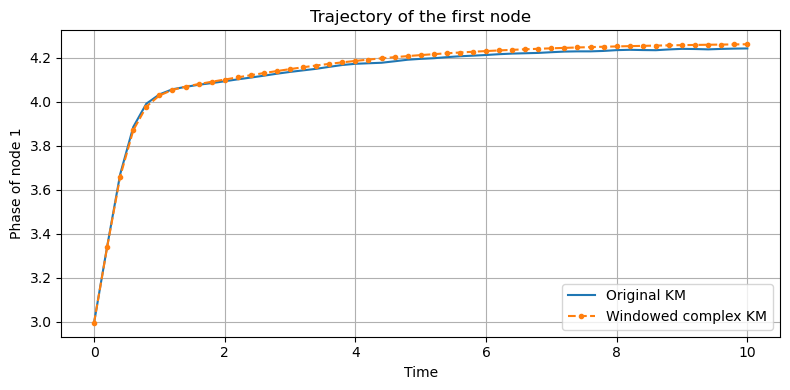

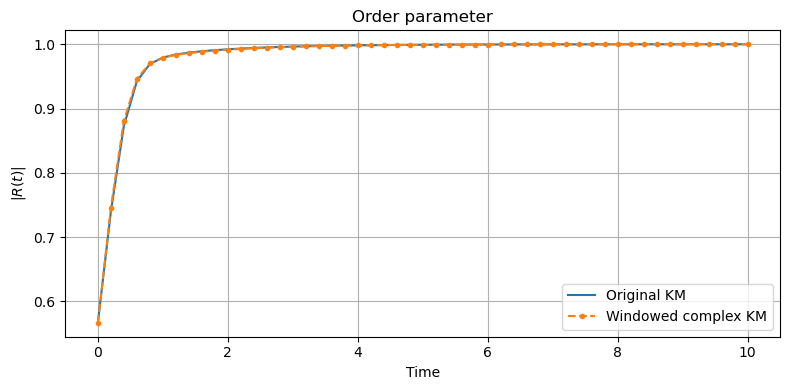

In [3]:
# Example experiment
rng = np.random.default_rng(1234)

N = 10
tau = 0.2
T = 10.0

graph = nx.cycle_graph(N)
theta_0 = rng.uniform(-np.pi, np.pi, size=N)

# Windowed complex-valued KM at times 0, tau, 2*tau, ..., T
windowed = windowed_complex_kuramoto_endpoints(
    graph=graph,
    initial_phases=theta_0,
    window_size=tau,
    final_time=T,
)

times = windowed["t"]
x_windowed = windowed["x"]

# Original KM evaluated at the same endpoint times
original = kuramoto_model(
    graph=graph,
    initial_conditions=theta_0,
    time_span=(0.0, T),
    time_points=times,
)

theta_original = original.y

# Order parameters
R_original = kuramoto_order_parameter(theta_original)
R_windowed = kuramoto_order_parameter(x_windowed)


# Compare the trajectory of node 1
plt.figure(figsize=(8, 4))

plt.plot(
    times,
    np.unwrap(theta_original[0]),
    label="Original KM",
)

plt.plot(
    times,
    np.unwrap(x_windowed[0]),
    "o--",
    markersize=3,
    label="Windowed complex KM",
)

plt.xlabel("Time")
plt.ylabel("Phase of node 1")
plt.title("Trajectory of the first node")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# Compare the order parameter
plt.figure(figsize=(8, 4))

plt.plot(
    times,
    np.abs(R_original),
    label="Original KM",
)

plt.plot(
    times,
    np.abs(R_windowed),
    "o--",
    markersize=3,
    label="Windowed complex KM",
)

plt.xlabel("Time")
plt.ylabel(r"$|R(t)|$")
plt.title("Order parameter")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

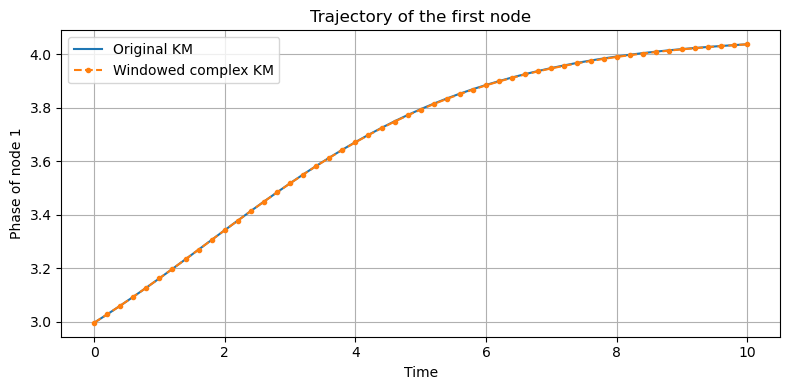

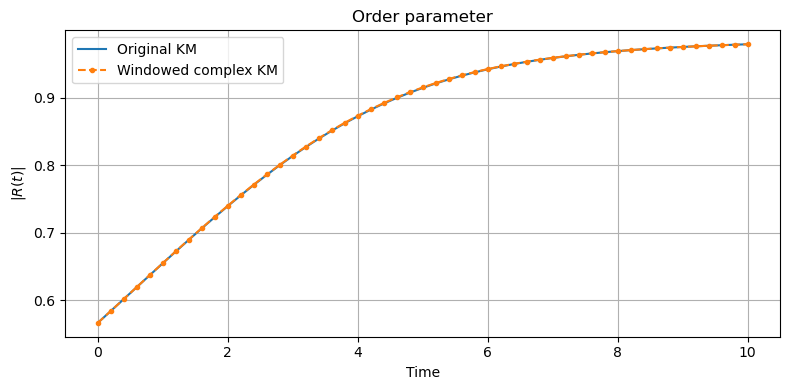

In [4]:
# Example experiment
rng = np.random.default_rng(1234)
N = 10
K = 1.0
tau = 0.2
T = 10.0

graph = nx.cycle_graph(N)


# Original adjacency matrix
A = nx.to_numpy_array(
    graph,
    weight="weight",
    dtype=float,
)

# Scaled adjacency matrix
A_scaled = (K / N) * A

theta_0 = rng.uniform(-np.pi, np.pi, size=N)

# Windowed complex-valued KM
windowed = windowed_complex_kuramoto_endpoints(
    graph=A_scaled,
    initial_phases=theta_0,
    window_size=tau,
    final_time=T,
)

times = windowed["t"]
x_windowed = windowed["x"]

# Original KM evaluated at the same endpoint times
original = kuramoto_model(
    graph=A_scaled,
    initial_conditions=theta_0,
    time_span=(0.0, T),
    time_points=times,
)

theta_original = original.y

# Order parameters
R_original = kuramoto_order_parameter(theta_original)
R_windowed = kuramoto_order_parameter(x_windowed)


# Compare the trajectory of node 1
plt.figure(figsize=(8, 4))

plt.plot(
    times,
    np.unwrap(theta_original[0]),
    label="Original KM",
)

plt.plot(
    times,
    np.unwrap(x_windowed[0]),
    "o--",
    markersize=3,
    label="Windowed complex KM",
)

plt.xlabel("Time")
plt.ylabel("Phase of node 1")
plt.title("Trajectory of the first node")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# Compare the order parameter
plt.figure(figsize=(8, 4))

plt.plot(
    times,
    np.abs(R_original),
    label="Original KM",
)

plt.plot(
    times,
    np.abs(R_windowed),
    "o--",
    markersize=3,
    label="Windowed complex KM",
)

plt.xlabel("Time")
plt.ylabel(r"$|R(t)|$")
plt.title("Order parameter")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Comparision of the KM and the complex-valued KM on a Erdos-Renyi graph with different window sizes.

Number of nodes: 20
Number of edges: 79
Graph seed: 1234


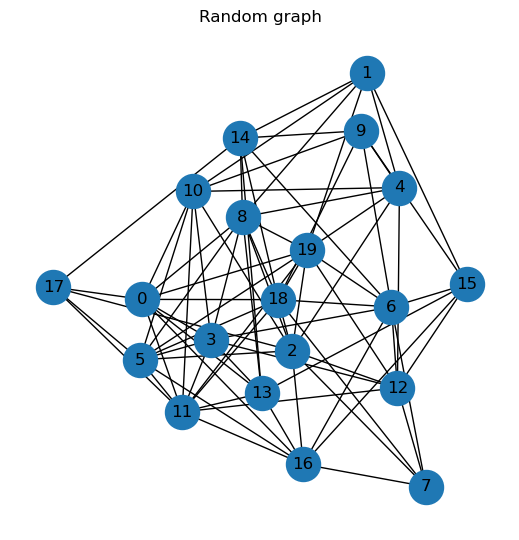

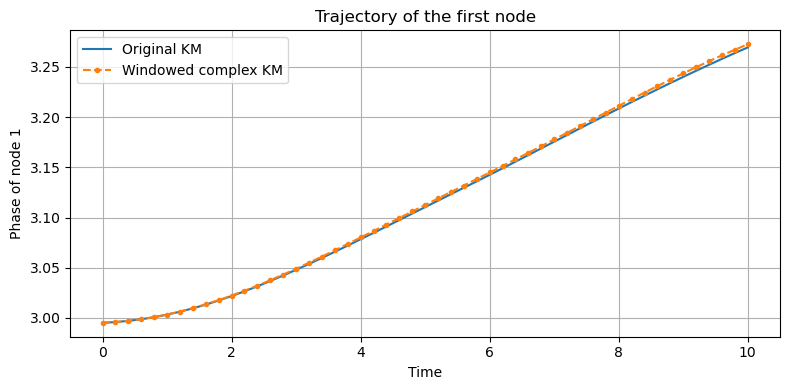

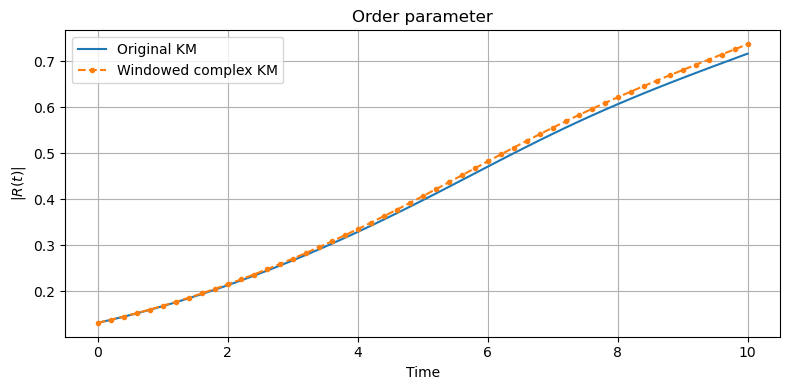

In [5]:
# Reproducible random experiment
seed = 1234
rng = np.random.default_rng(seed)

N = 20
K = 1.0
p = 0.4       # Probability that each possible edge is present
tau = 0.2
T = 10.0


# ------------------------------------------------------------
# Generate a connected random graph
# ------------------------------------------------------------

graph_seed = seed

while True:
    graph = nx.erdos_renyi_graph(
        n=N,
        p=p,
        seed=graph_seed,
    )

    if nx.is_connected(graph):
        break

    graph_seed += 1


# ------------------------------------------------------------
# Save the graph and adjacency matrices
# ------------------------------------------------------------

# Save the NetworkX graph
nx.write_graphml(graph, "random_graph_N10.graphml")

# Unscaled adjacency matrix
A = nx.to_numpy_array(
    graph,
    nodelist=range(N),
    dtype=float,
)

# Scaled adjacency matrix
A_scaled = (K / N) * A

np.save("random_graph_adjacency.npy", A)
np.save("random_graph_adjacency_scaled.npy", A_scaled)

print("Number of nodes:", graph.number_of_nodes())
print("Number of edges:", graph.number_of_edges())
print("Graph seed:", graph_seed)


# ------------------------------------------------------------
# Generate and save initial phases
# ------------------------------------------------------------

theta_0 = rng.uniform(
    -np.pi,
    np.pi,
    size=N,
)

np.save("initial_phases.npy", theta_0)


# ------------------------------------------------------------
# Run the windowed complex-valued KM
# ------------------------------------------------------------

windowed = windowed_complex_kuramoto_endpoints(
    graph=A_scaled,
    initial_phases=theta_0,
    window_size=tau,
    final_time=T,
)

times = windowed["t"]
x_windowed = windowed["x"]


# ------------------------------------------------------------
# Run the original KM at the same times
# ------------------------------------------------------------

original = kuramoto_model(
    graph=A_scaled,
    initial_conditions=theta_0,
    time_span=(0.0, T),
    time_points=times,
)

theta_original = original.y


# ------------------------------------------------------------
# Calculate the order parameters
# ------------------------------------------------------------

R_original = kuramoto_order_parameter(theta_original)
R_windowed = kuramoto_order_parameter(x_windowed)


# ------------------------------------------------------------
# Plot the random graph
# ------------------------------------------------------------

plt.figure(figsize=(5, 5))

position = nx.spring_layout(
    graph,
    seed=seed,
)

nx.draw(
    graph,
    position,
    with_labels=True,
    node_size=600,
)

plt.title("Random graph")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Compare the trajectory of node 1
# ------------------------------------------------------------

plt.figure(figsize=(8, 4))

plt.plot(
    times,
    np.unwrap(theta_original[0]),
    label="Original KM",
)

plt.plot(
    times,
    np.unwrap(x_windowed[0]),
    "o--",
    markersize=3,
    label="Windowed complex KM",
)

plt.xlabel("Time")
plt.ylabel("Phase of node 1")
plt.title("Trajectory of the first node")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Compare the order parameters
# ------------------------------------------------------------

plt.figure(figsize=(8, 4))

plt.plot(
    times,
    np.abs(R_original),
    label="Original KM",
)

plt.plot(
    times,
    np.abs(R_windowed),
    "o--",
    markersize=3,
    label="Windowed complex KM",
)

plt.xlabel("Time")
plt.ylabel(r"$|R(t)|$")
plt.title("Order parameter")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

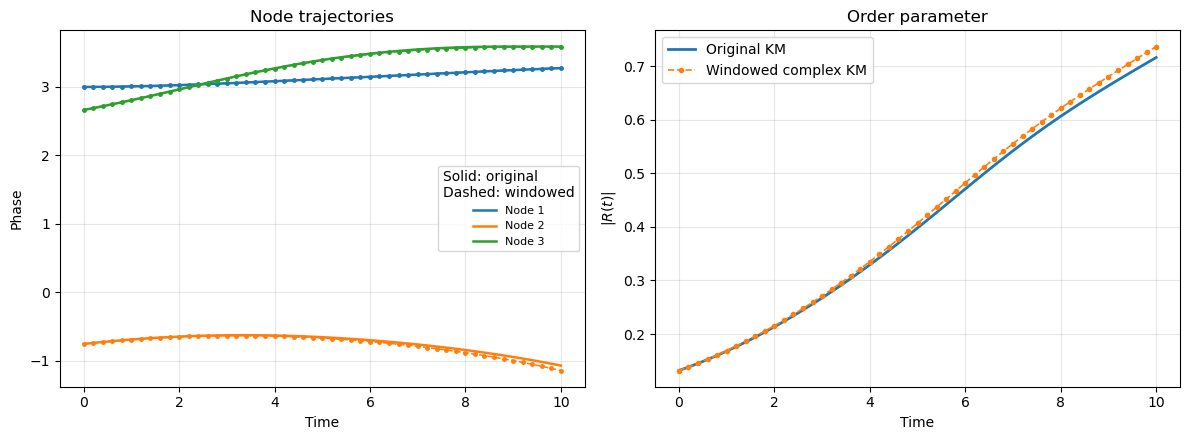

In [6]:
# Select three nodes
nodes_to_plot = [0, 1, 2]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
)

# ------------------------------------------------------------
# Left panel: trajectories of three nodes
# Same color for each node; line style distinguishes the models
# ------------------------------------------------------------

for node in nodes_to_plot:
    original_line = axes[0].plot(
        times,
        np.unwrap(theta_original[node]),
        linewidth=1.8,
        label=rf"Node {node + 1}",
    )[0]

    axes[0].plot(
        times,
        np.unwrap(x_windowed[node]),
        "o--",
        markersize=2.5,
        linewidth=1.1,
        color=original_line.get_color(),
    )

axes[0].set_xlabel("Time")
axes[0].set_ylabel("Phase")
axes[0].set_title("Node trajectories")
axes[0].grid(True, alpha=0.3)
axes[0].legend(
    title="Solid: original\nDashed: windowed",
    fontsize=8,
)


# ------------------------------------------------------------
# Right panel: order parameter
# ------------------------------------------------------------

axes[1].plot(
    times,
    np.abs(R_original),
    linewidth=2,
    label="Original KM",
)

axes[1].plot(
    times,
    np.abs(R_windowed),
    "o--",
    markersize=3,
    linewidth=1.2,
    label="Windowed complex KM",
)

axes[1].set_xlabel("Time")
axes[1].set_ylabel(r"$|R(t)|$")
axes[1].set_title("Order parameter")
axes[1].grid(True, alpha=0.3)
axes[1].legend()


# ------------------------------------------------------------
# Save as PDF and display
# ------------------------------------------------------------

fig.tight_layout()

fig.savefig(
    "kuramoto_comparison_erdos_renyi.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()

In [7]:
tau_values = {
    1: "kuramoto_tau_1.pdf",
    0.2: "kuramoto_tau_0_2.pdf",
    0.01: "kuramoto_tau_0_01.pdf",
}

nodes_to_plot = [0, 1, 2]

for tau, filename in tau_values.items():

    windowed = windowed_complex_kuramoto_endpoints(
        graph=A_scaled,
        initial_phases=theta_0,
        window_size=tau,
        final_time=T,
    )

    times = windowed["t"]
    x_windowed = windowed["x"]

    original = kuramoto_model(
        graph=A_scaled,
        initial_conditions=theta_0,
        time_span=(0.0, T),
        time_points=times,
    )

    theta_original = original.y

    R_original = kuramoto_order_parameter(theta_original)
    R_windowed = kuramoto_order_parameter(x_windowed)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    for node in nodes_to_plot:
        line = axes[0].plot(
            times,
            np.unwrap(theta_original[node]),
            linewidth=1.8,
            label=rf"Node {node + 1}",
        )[0]

        axes[0].plot(
            times,
            np.unwrap(x_windowed[node]),
            "o--",
            markersize=2.5,
            linewidth=1.1,
            color=line.get_color(),
        )

    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("Phase")
    axes[0].set_title(rf"Node trajectories, $\tau={tau}$")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(
        title="Solid: original\nDashed: windowed",
        fontsize=8,
    )

    axes[1].plot(
        times,
        np.abs(R_original),
        linewidth=2,
        label="Original KM",
    )

    axes[1].plot(
        times,
        np.abs(R_windowed),
        "o--",
        markersize=3,
        linewidth=1.2,
        label="Windowed complex KM",
    )

    axes[1].set_xlabel("Time")
    axes[1].set_ylabel(r"$|R(t)|$")
    axes[1].set_title(rf"Order parameter, $\tau={tau}$")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(filename, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved {filename}")

Saved kuramoto_tau_1.pdf
Saved kuramoto_tau_0_2.pdf
Saved kuramoto_tau_0_01.pdf


# Global error as a function of $\tau$ 

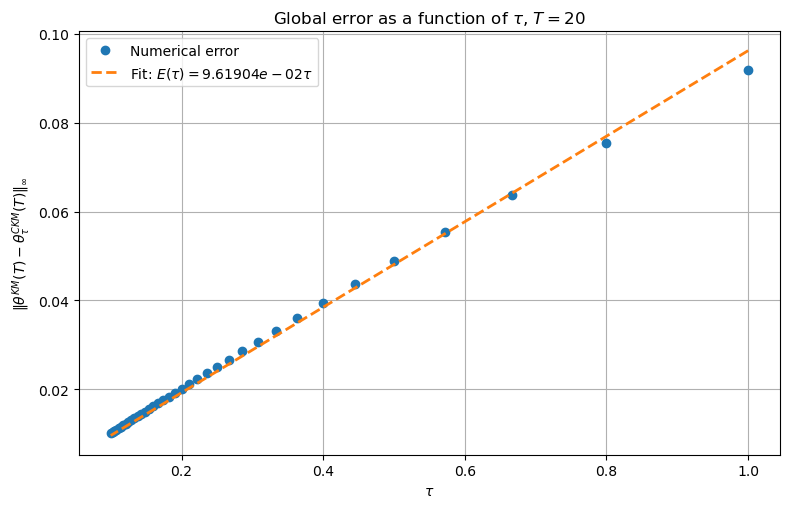

In [18]:

# ============================================================
# Scale adjacency matrix by N
# ============================================================

graph = np.load("random_graph_adjacency_scaled.npy")

N = graph.shape[0]


# ============================================================
# Initial condition
# ============================================================

rng = np.random.default_rng(1)

theta_0 = rng.uniform(
    -np.pi,
    np.pi,
    N
)


# ============================================================
# Fixed final time
# ============================================================

T = 20.0

num_windows_values = np.array([5*i for i in range(4, 41)]) 

tau_values = T / num_windows_values


# ============================================================
# Original Kuramoto model
#
# Compute only once, since it does not depend on tau
# ============================================================

km = kuramoto_model(
    graph=graph,
    initial_conditions=theta_0,
    coupling_strength=1.0,
    time_span=(0.0, T),
    time_points=[T],
)

theta_km_T = km.y[:, -1]


# ============================================================
# Window sizes
#
# Each tau divides T exactly
# ============================================================


# ============================================================
# Compute circular error at T
# ============================================================

errors = []

for tau in tau_values:

    windowed = windowed_complex_kuramoto_endpoints(
        graph=graph,
        initial_phases=theta_0,
        window_size=tau,
        final_time=T,
    )

    theta_complex_T = windowed["x"][:, -1]


    # --------------------------------------------------------
    # Circular phase difference
    #
    # Each difference lies in (-pi, pi]
    # --------------------------------------------------------

    phase_difference = np.angle(
        np.exp(
            1j * (
                theta_km_T
                - theta_complex_T
            )
        )
    )


    # --------------------------------------------------------
    # Maximum circular distance over all oscillators
    # --------------------------------------------------------

    error = np.max(
        np.abs(phase_difference)
    )

    errors.append(error)


errors = np.asarray(errors)


# ============================================================
# Linear fit through the origin
#
# E(tau) approximately C tau
# ============================================================

slope = (
    np.dot(tau_values, errors)
    / np.dot(tau_values, tau_values)
)

error_fit = slope * tau_values


# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    tau_values,
    errors,
    "o",
    markersize=6,
    label="Numerical error",
)

plt.plot(
    tau_values,
    error_fit,
    "--",
    linewidth=2,
    label=rf"Fit: $E(\tau)={slope:.5e}\tau$",
)

plt.xlabel(r"$\tau$")

plt.ylabel(
    r"$\max_i\, d_{S^1}"
    r"(\theta_i^{KM}(T),\theta_i^{CKM}(T))$"
)
plt.ylabel(
    r"$\|\theta^{KM}(T)-\theta^{CKM}_{\tau}(T)\|_{\infty}$"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.title(r"Global error as a function of $\tau$, "
          r"$T=20$")
plt.savefig(
    "global_error.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()

# Model error in one window. 

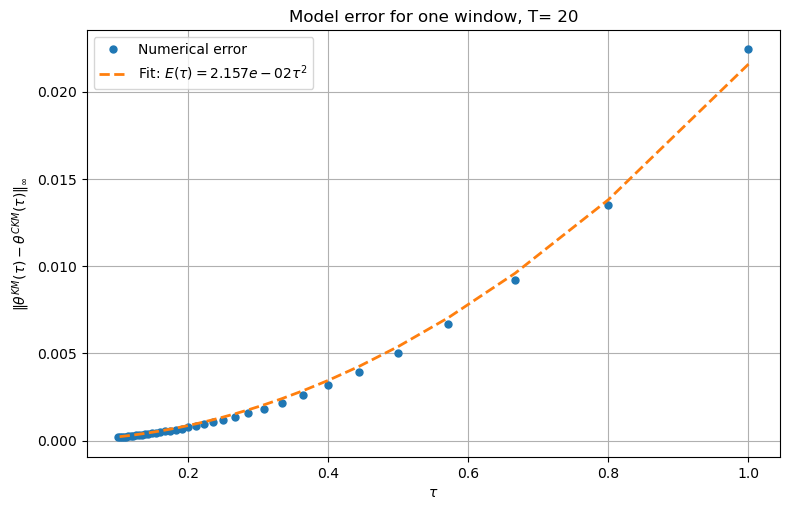

In [17]:

# ============================================================
# Load scaled adjacency matrix
# ============================================================
graph = np.load("random_graph_adjacency_scaled.npy")

N = graph.shape[0]


# ============================================================
# Initial condition
# ============================================================

rng = np.random.default_rng(1)

theta_0 = rng.uniform(
    -np.pi,
    np.pi,
    N
)


# ============================================================
# Reference final time used only to define tau values
# ============================================================

T = 20.0

num_windows_values = np.array([5*i for i in range(4, 41)]) 

tau_values = T / num_windows_values

#tau_values = np.arange(0.02, 1.02, 0.02)

# ============================================================
# Error at the end of the FIRST window
#
# Compare both models at t = tau
# ============================================================

errors = []

for tau in tau_values:

    # --------------------------------------------------------
    # Original KM at t = tau
    # --------------------------------------------------------

    km = kuramoto_model(
        graph=graph,
        initial_conditions=theta_0,
        coupling_strength=1.0,
        time_span=(0.0, tau),
        time_points=[tau],
    )

    theta_km_tau = km.y[:, -1]


    # --------------------------------------------------------
    # Complex-valued KM: one window of length tau
    # --------------------------------------------------------

    windowed = windowed_complex_kuramoto_endpoints(
        graph=graph,
        initial_phases=theta_0,
        window_size=tau,
        number_of_windows=1,
    )

    # column 0 = t = 0
    # column 1 = t = tau
    theta_complex_tau = windowed["x"][:, 1]


    # --------------------------------------------------------
    # Circular phase difference
    # --------------------------------------------------------

    phase_difference = np.angle(
        np.exp(
            1j * (
                theta_km_tau
                - theta_complex_tau
            )
        )
    )


    # --------------------------------------------------------
    # Maximum circular distance
    # --------------------------------------------------------

    error = np.max(
        np.abs(phase_difference)
    )

    errors.append(error)


errors = np.asarray(errors)
a, b, c = np.polyfit(
    tau_values,
    errors,
    2,
)

x = tau_values**2

C = np.dot(x, errors) / np.dot(x, x)

error_fit = C * tau_values**2


# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    tau_values,
    errors,
    "o",
    markersize=5,
    label="Numerical error",
)

plt.plot(
    tau_values,
    error_fit,
    "--",
    linewidth=2,
    label=rf"Fit: $E(\tau)={C:.3e}\tau^2$",
)

plt.xlabel(r"$\tau$")

plt.ylabel(
    r"$\|\theta^{KM}(\tau)-\theta^{CKM}(\tau)\|_{\infty}$"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.title("Model error for one window, T= 20")
plt.savefig(
    "model_error_one_window.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()

In [19]:
tau_values

array([1.        , 0.8       , 0.66666667, 0.57142857, 0.5       ,
       0.44444444, 0.4       , 0.36363636, 0.33333333, 0.30769231,
       0.28571429, 0.26666667, 0.25      , 0.23529412, 0.22222222,
       0.21052632, 0.2       , 0.19047619, 0.18181818, 0.17391304,
       0.16666667, 0.16      , 0.15384615, 0.14814815, 0.14285714,
       0.13793103, 0.13333333, 0.12903226, 0.125     , 0.12121212,
       0.11764706, 0.11428571, 0.11111111, 0.10810811, 0.10526316,
       0.1025641 , 0.1       ])